<a href="https://colab.research.google.com/github/Marcel-12345/PCVK_Ganjil_2026/blob/main/PCVKWeek5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NAMA : Anselmus Marcel Putra Andria
NIM : 244107020141 | N = 141
bins   : 16
clip   : 1.5
tile   : 3
L      : 2
WAKTU : 2026-09-26 23:34:18 WIB
SISTEM : 3.13.15 Linux-6.6.122+-x86_64-with-glibc2.39
TOKEN : 4dce3eb274ee02f3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Pertanyaan praktikum 1
=== UJI PERBANDINGAN HISTOGRAM: lena.jpg ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0
-> PEMBUKTIAN BERHASIL: Ketiga metode menghasilkan nilai yang identik (selisih = 0).

=== UJI PERBANDINGAN HISTOGRAM: KTM1b.jpg ===
Selisih Maksimum (Manual vs NumPy) : 0
Selisih Maksimum (Manual vs OpenCV): 0.0
Selisih Maksimum (NumPy vs OpenCV) : 0.0
-> PEMBUKTIAN BERHASIL: Ketiga metode menghasilkan nilai yang identik (selisih = 0).



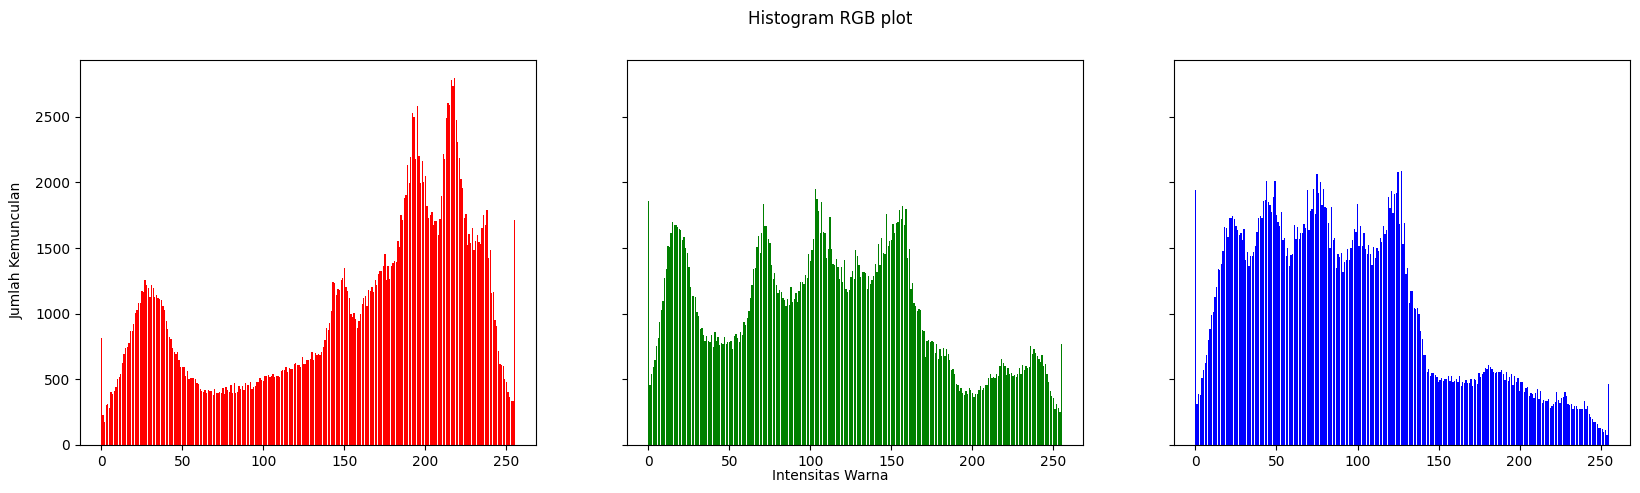

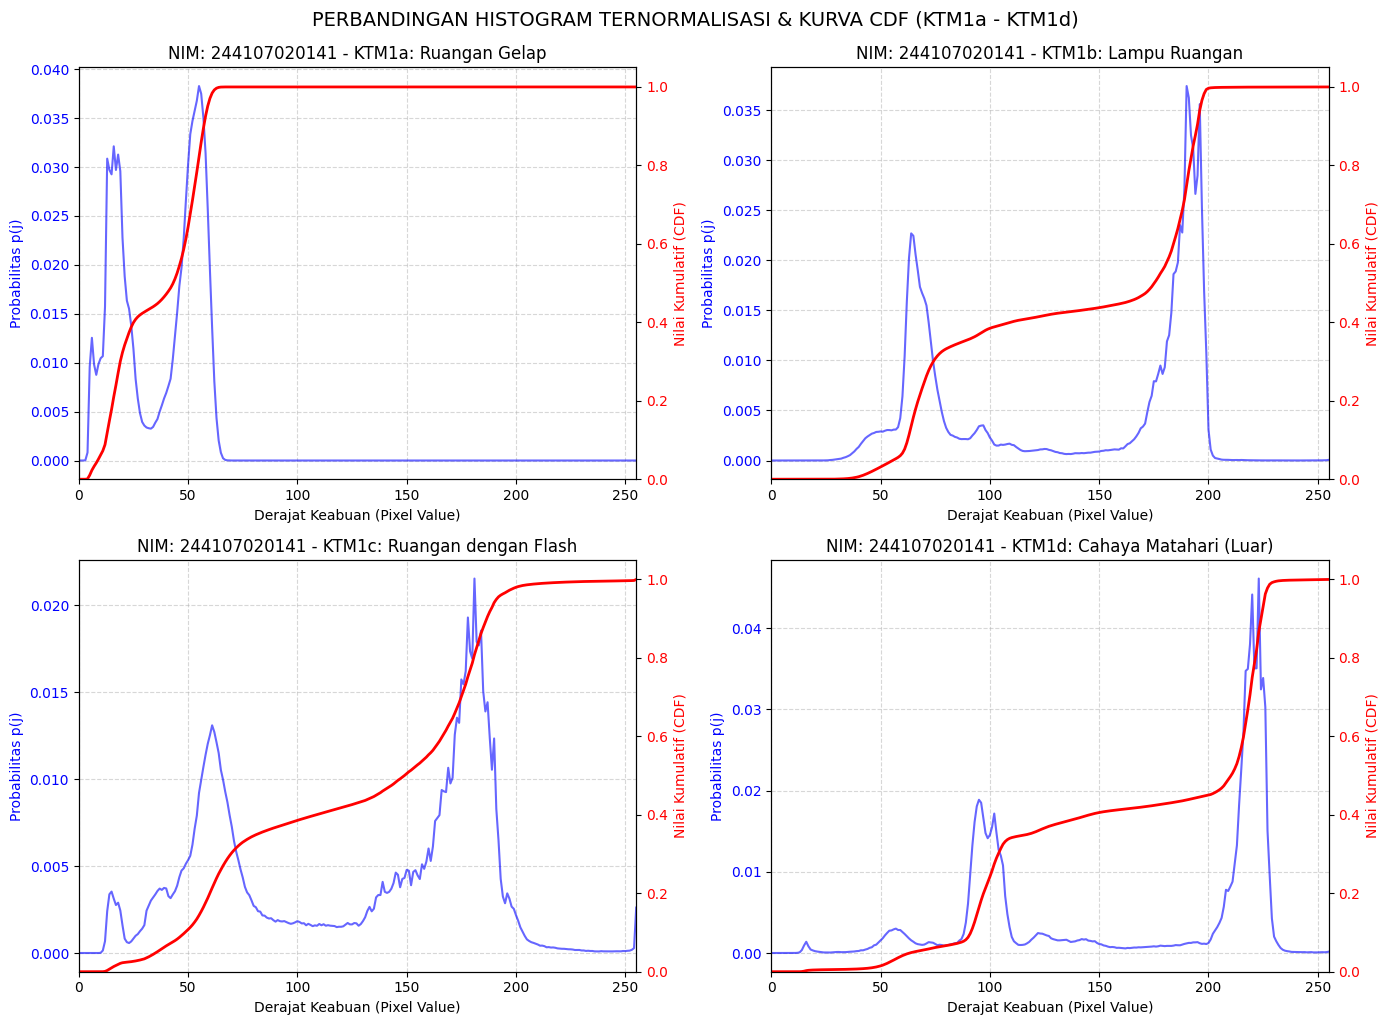

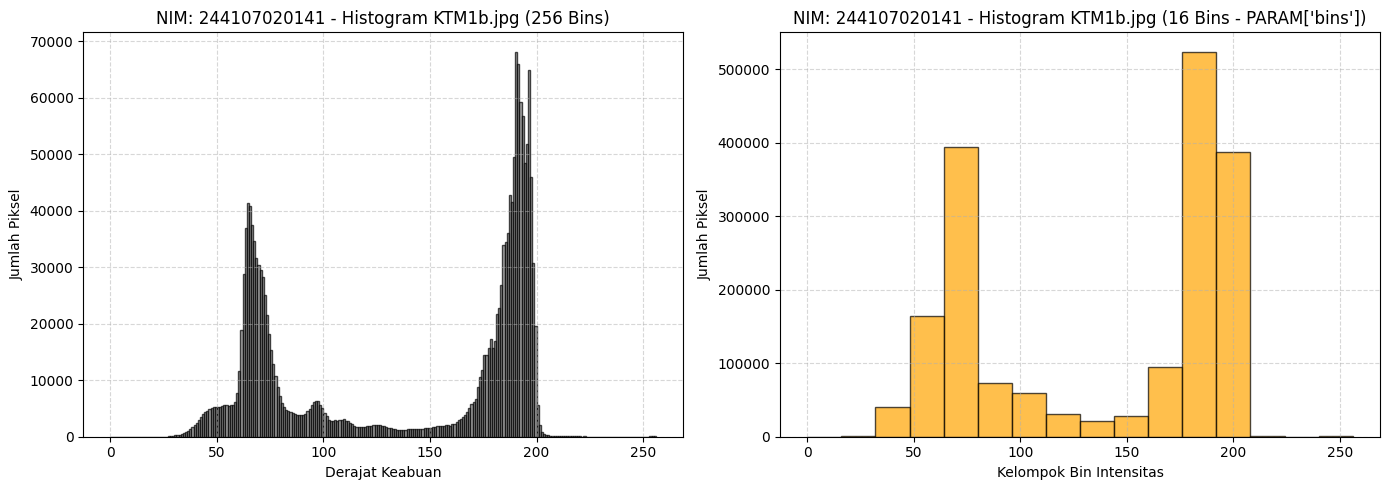

Praktikum 2 - PERCOBAAN HISTOGRAM EQUALIZATION
=== PERCOBAAN 1: HISTOGRAM EQUALIZATION MANUAL (lena_lc.jpg) ===


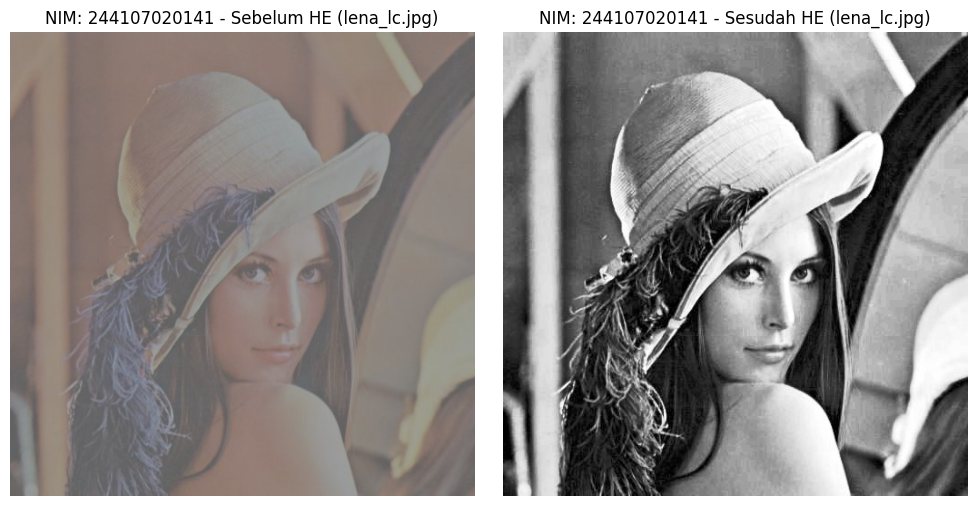

=== PERCOBAAN 1: HISTOGRAM EQUALIZATION MANUAL (KTM1a.jpg) ===


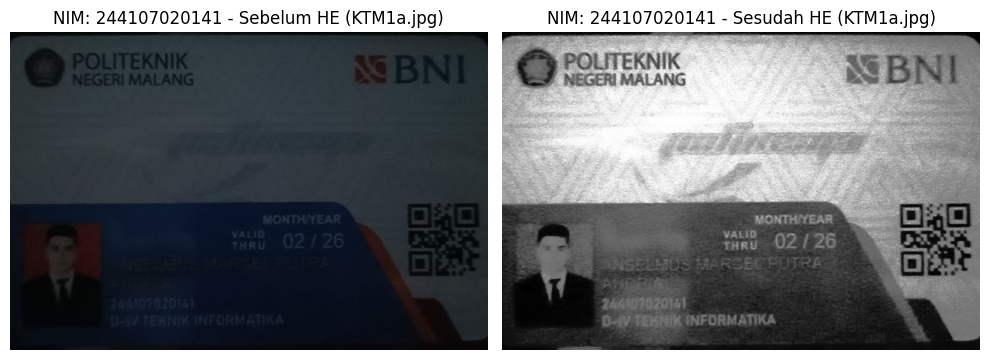

=== PERCOBAAN 2: PERBANDINGAN MANUAL VS CV2.EQUALIZEHIST (lena_lc.jpg) ===
Selisih maksimum hasil cv2.equalizeHist vs Manual (lena_lc.jpg): 0
-> Hasil identik sempurna (selisih = 0).

=== PERCOBAAN 2: PERBANDINGAN MANUAL VS CV2.EQUALIZEHIST (KTM1a.jpg) ===
Selisih maksimum hasil cv2.equalizeHist vs Manual (KTM1a.jpg): 1
-> Terdapat perbedaan tipis akibat pembulatan (rounding/floating point) pada CDF.



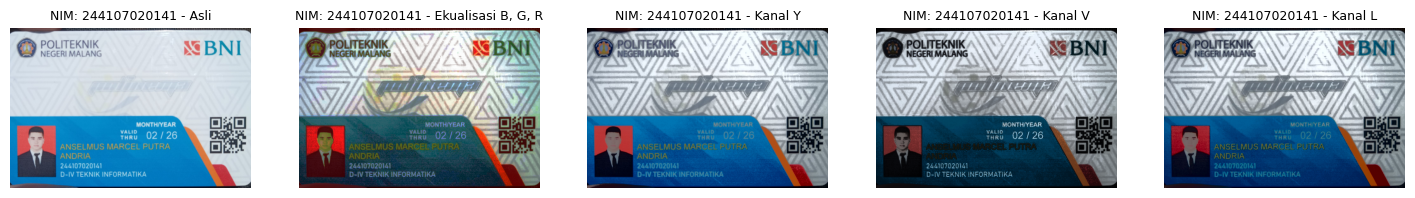


Cara                    geser Hue (der)    rerata terang
Asli                               0.00            167.6
Ekualisasi B, G, R                57.22            128.3
Kanal Y                            2.34            133.1
Kanal V                            2.03            114.5
Kanal L                            4.49            123.4

[HASIL CLAHE (clipLimit=1.5, tileGridSize=(3,3))]
Rata-rata Pergeseran Hue (derajat) : 1.55
Rerata Kecerahan Sesudah CLAHE     : 163.6
Pertanyaan praktikum 2


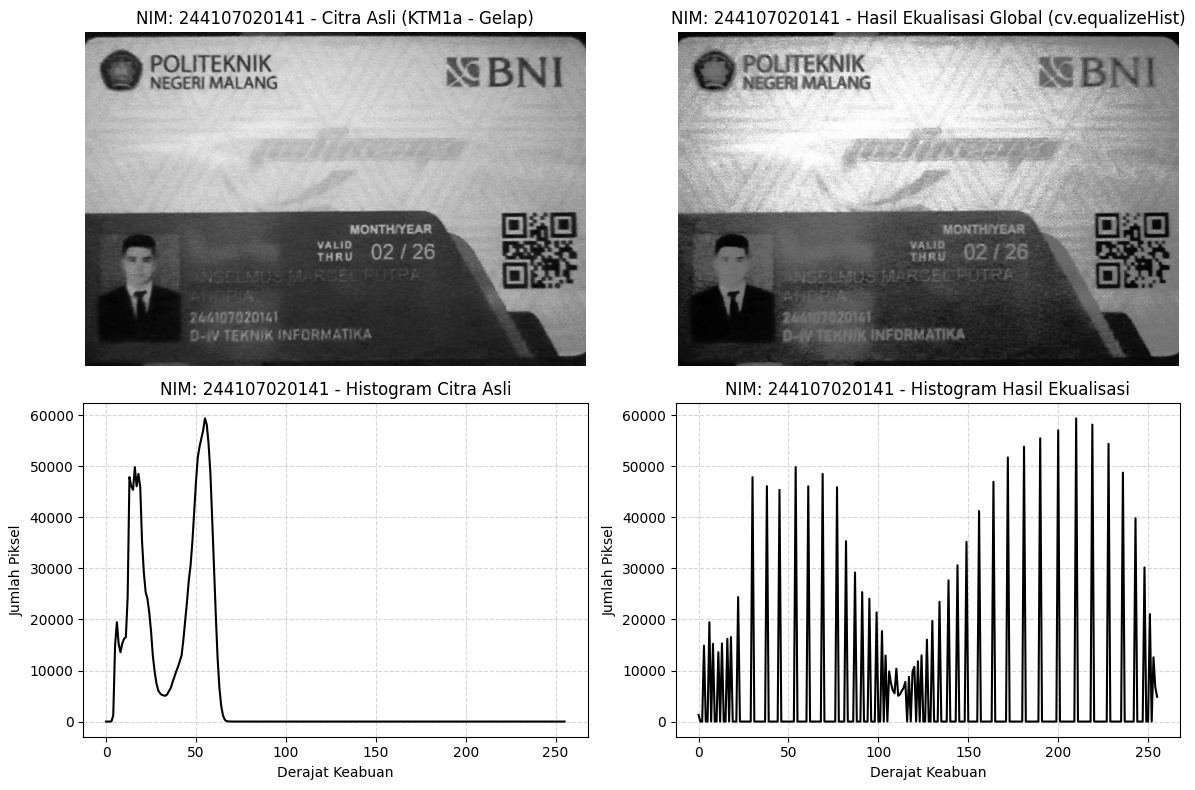

=== HASIL PSNR EKUALISASI GLOBAL ===
Nilai PSNR antara Citra Asli dan Hasil Ekualisasi Global: 7.34 dB



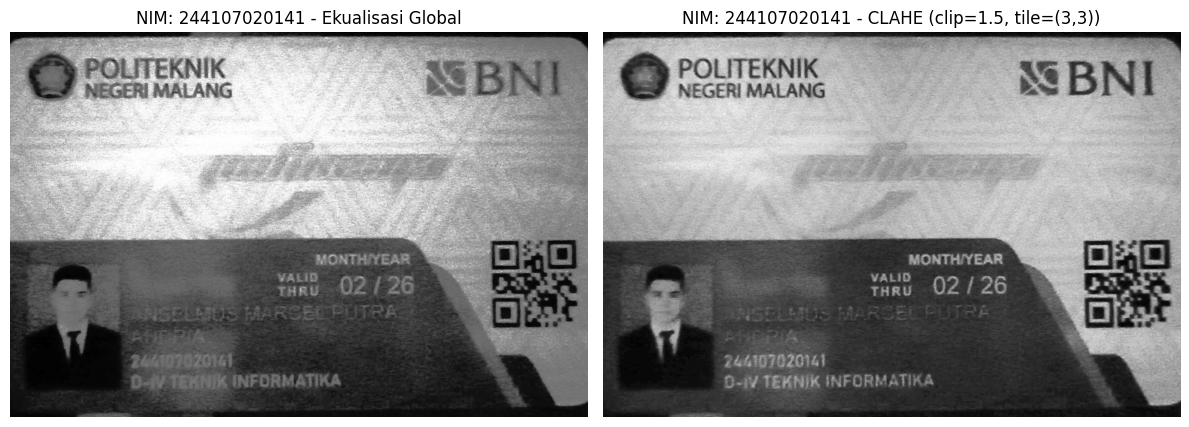

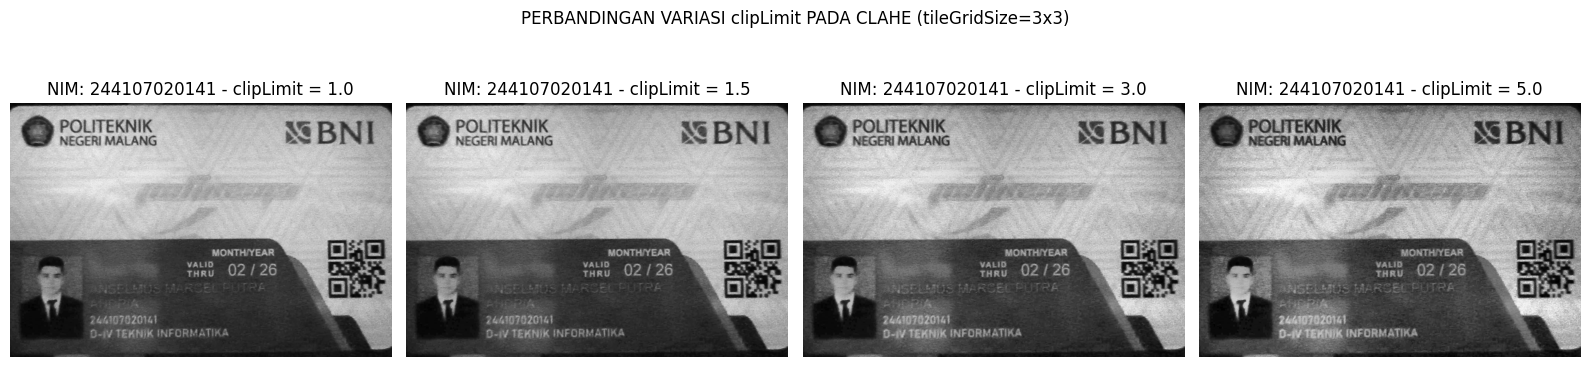

In [6]:
# SEL IDENTITAS
import sys, platform, hashlib, datetime, zoneinfo
NAMA = 'Anselmus Marcel Putra Andria'
NIM = '244107020141'
N = int(NIM[-3:])
PARAM = {
'bins' : 2 ** ((N % 4) + 3),
'clip' : round(1.0 + (N % 5) * 0.5, 1),
'tile' : (N % 4) + 2,
'L' : 2 ** ((N % 3) + 1),
}
waktu = datetime.datetime.now(zoneinfo.ZoneInfo('Asia/Jakarta'))

print('NAMA :', NAMA)
print('NIM :', NIM, '| N =', N)
for k, v in PARAM.items():
  print('%-6s :' % k, v)
print('WAKTU :', waktu.strftime('%Y-%m-%d %H:%M:%S %Z'))
print('SISTEM :', sys.version.split()[0], platform.platform())
kunci = NIM + '|' + waktu.strftime('%Y-%m-%d')
print('TOKEN :', hashlib.sha256(kunci.encode()).hexdigest()[:16])

# IMPORT
from google.colab import drive
drive.mount('/content/drive')
import cv2 as cv
from google.colab.patches import cv2_imshow
from skimage import io
import matplotlib.pyplot as plt
import numpy as np
import math
import os
import glob

# Membuat histogram image (manual)
img = cv.imread("/content/drive/MyDrive/PCVK/lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
height, width, depth = np.shape(img)
names = np.arange(256)

red = [0]*256
blue = [0]*256
green = [0]*256
for y in range(0,height):
  for x in range(0,width):
    red[img[y][x] [0]] += 1
    green[img[y][x] [1]] += 1
    blue[img[y][x] [2]] += 1

names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20,5), sharex = True, sharey=True)
fig.suptitle('Histogram RGB plot')
fig.text(0.09, 0.5, 'Jumlah Kemunculan', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Intensitas Warna', ha='center')
axs[0].bar(names, red, color = 'red')
axs[1].bar(names, green, color = 'green')
axs[2].bar(names, blue, color = 'blue')

# PERTANYAAN PRAKTIKUM 1
print("Pertanyaan praktikum 1")

# ==============================================================================
# SETUP AWAL & DEFINISI FUNGSI HISTOGRAM MANUAL
# ==============================================================================
# Path direktori penyimpanan gambar (sesuaikan jika menggunakan Google Drive)
BASE_PATH = '/content/drive/MyDrive/PCVK/Images/244107020141/'

def histogram_manual(img, L=256):
    """Fungsi histogram manual sesuai modul teori[cite: 1]"""
    h = np.zeros(L, dtype=np.int64)
    for y in range(img.shape[0]):
        for x in range(img.shape[1]):
            h[img[y, x]] += 1
    return h

# ==============================================================================
# SOAL 1: PERBANDINGAN HISTOGRAM MANUAL, NUMPY, DAN OPENCV
# ==============================================================================
def uji_perbandingan_histogram(filename):
    print(f"=== UJI PERBANDINGAN HISTOGRAM: {filename} ===")

    # 1. Load Citra (Grayscale)
    img = cv.imread(BASE_PATH + filename, cv.IMREAD_GRAYSCALE)
    if img is None:
        print(f"Gagal memuat gambar: {filename}. Pastikan file tersedia.")
        return

    # 2. Perhitungan Histogram dengan 3 Metode
    hist_manual = histogram_manual(img)
    hist_numpy, _ = np.histogram(img.ravel(), bins=256, range=[0, 256])
    hist_cv = cv.calcHist([img], [0], None, [256], [0, 256]).ravel()

    # 3. Hitung Selisih Maksimum
    diff_manual_numpy = np.max(np.abs(hist_manual - hist_numpy))
    diff_manual_cv = np.max(np.abs(hist_manual - hist_cv))
    diff_numpy_cv = np.max(np.abs(hist_numpy - hist_cv))

    # 4. Tampilkan Hasil Pembuktian
    print(f"Selisih Maksimum (Manual vs NumPy) : {diff_manual_numpy}")
    print(f"Selisih Maksimum (Manual vs OpenCV): {diff_manual_cv}")
    print(f"Selisih Maksimum (NumPy vs OpenCV) : {diff_numpy_cv}")

    if diff_manual_numpy == 0 and diff_manual_cv == 0:
        print("-> PEMBUKTIAN BERHASIL: Ketiga metode menghasilkan nilai yang identik (selisih = 0).\n")
    else:
        print("-> PEMBUKTIAN GAGAL: Terdapat perbedaan pada hasil perhitungan.\n")

# Eksekusi Soal 1
uji_perbandingan_histogram('lena.jpg')   # Uji pada lena.jpg[cite: 2]
uji_perbandingan_histogram('KTM1b.jpg')  # Ulangi pada KTM1b.jpg[cite: 2]


# ==============================================================================
# SOAL 2: HISTOGRAM TERNORMALISASI p(j) & KURVA CDF (2x2 FIGURE)
# ==============================================================================
ktm_files = ['KTM1a.jpg', 'KTM1b.jpg', 'KTM1c.jpg', 'KTM1d.jpg']
ktm_titles = [
    'KTM1a: Ruangan Gelap',
    'KTM1b: Lampu Ruangan',
    'KTM1c: Ruangan dengan Flash',
    'KTM1d: Cahaya Matahari (Luar)'
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

for i, filename in enumerate(ktm_files):
    img = cv.imread(BASE_PATH + filename, cv.IMREAD_GRAYSCALE)
    if img is None:
        continue

    # Hitung Histogram, Normalisasi p(j), dan CDF
    h = cv.calcHist([img], [0], None, [256], [0, 256]).ravel()
    p_j = h / img.size
    cdf = np.cumsum(p_j)

    # Sumbu X (Derajat Keabuan 0-255)
    bins_x = np.arange(256)

    # Plotting p(j) pada Sumbu Kiri (Bar/Line)
    ax1 = axes[i]
    ax1.plot(bins_x, p_j, color='blue', alpha=0.6, label='Histogram Ternormalisasi p(j)')
    ax1.set_xlabel('Derajat Keabuan (Pixel Value)')
    ax1.set_ylabel('Probabilitas p(j)', color='blue')
    ax1.tick_params(axis='y', labelcolor='blue')
    ax1.set_xlim([0, 255])

    # Plotting CDF pada Sumbu Kanan (Sumbu Ganda)
    ax2 = ax1.twinx()
    ax2.plot(bins_x, cdf, color='red', linewidth=2, label='Kurva CDF')
    ax2.set_ylabel('Nilai Kumulatif (CDF)', color='red')
    ax2.tick_params(axis='y', labelcolor='red')
    ax2.set_ylim([0, 1.05])

    # Judul Gambar (Termasuk NIM dari variabel PARAM/NIM jika tersedia)
    title_prefix = f"NIM: {NIM} - " if 'NIM' in globals() else ""
    ax1.set_title(f"{title_prefix}{ktm_titles[i]}")
    ax1.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.suptitle('PERBANDINGAN HISTOGRAM TERNORMALISASI & KURVA CDF (KTM1a - KTM1d)', fontsize=14, y=1.02)
plt.show()

# --- PENJELASAN SOAL 2 (Tuliskan analisis ini pada Laporan Praktikum Anda) ---
"""
ANALISIS SOAL 2:
1. Citra Paling Gelap (KTM1a - Gelap):
   - Distribusi p(j) menumpuk di area kiri (nilai intensitas rendah/mendekati 0).
   - Kurva CDF naik sangat curam di awal (intensitas rendah) lalu mendatar
     mendekati nilai 1 sebelum mencapai pertengahan nilai piksel.
   - Kondisi Akuisisi: Minim intensitas cahaya masuk ke sensor kamera, sehingga
     sebagian besar piksel bernilai gelap/hitam.

2. Citra Paling Terang (KTM1c / KTM1d - Flash / Cahaya Matahari):
   - Distribusi p(j) bergeser dominan ke area kanan (nilai intensitas tinggi/mendekati 255).
   - Kurva CDF bernilai mendekati 0 di awal, lalu melonjak curam di area intensitas
     terang (kanan) hingga mencapai nilai 1.
   - Kondisi Akuisisi: Pencahayaan tinggi/berlebih saat pengambilan gambar
     membuat piksel terdominasi oleh warna terang/putih.
"""


# ==============================================================================
# SOAL 3: PERBANDINGAN HISTOGRAM BINS PARAM['bins'] VS 256 BINS
# ==============================================================================
# Mengambil nilai PARAM['bins'] dari Sel Identitas, jika belum ada default ke 32
num_bins = PARAM['bins'] if 'PARAM' in globals() and 'bins' in PARAM else 32

img_ktm1b = cv.imread(BASE_PATH + 'KTM1b.jpg', cv.IMREAD_GRAYSCALE)

if img_ktm1b is not None:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    title_prefix = f"NIM: {NIM} - " if 'NIM' in globals() else ""

    # 1. Histogram dengan 256 Bins
    axes[0].hist(img_ktm1b.ravel(), bins=256, range=[0, 256], color='gray', edgecolor='black', alpha=0.7)
    axes[0].set_title(f"{title_prefix}Histogram KTM1b.jpg (256 Bins)")
    axes[0].set_xlabel('Derajat Keabuan')
    axes[0].set_ylabel('Jumlah Piksel')
    axes[0].grid(True, linestyle='--', alpha=0.5)

    # 2. Histogram dengan PARAM['bins']
    axes[1].hist(img_ktm1b.ravel(), bins=num_bins, range=[0, 256], color='orange', edgecolor='black', alpha=0.7)
    axes[1].set_title(f"{title_prefix}Histogram KTM1b.jpg ({num_bins} Bins - PARAM['bins'])")
    axes[1].set_xlabel('Kelompok Bin Intensitas')
    axes[1].set_ylabel('Jumlah Piksel')
    axes[1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

# --- PENJELASAN SOAL 3 (Tuliskan analisis ini pada Laporan Praktikum Anda) ---
"""
ANALISIS SOAL 3:
Informasi yang hilang saat jumlah bin dikurangi:
Ketika jumlah bin dikurangi dari 256 menjadi {num_bins} bin, terjadi pengelompokan
(binning/quantization) beberapa nilai intensitas piksel yang berdekatan ke dalam
satu interval bin yang sama.

Informasi detail mengenai variasi pencahayaan halus (fine details), kontras mikro,
dan fluktuasi distribusi intensitas spesifik antar-nilai piksel tunggal menjadi hilang/tersamar.
Histogram menjadi lebih mulus (smooth) dan tergeneralisasi, sehingga kita tidak lagi
dapat melihat frekuensi persis dari masing-masing tingkat keabuan (0-255).
"""

# PRAKTIKUM 2 - PERCOBAAN HISTOGRAM EQUALIZATION
print("Praktikum 2 - PERCOBAAN HISTOGRAM EQUALIZATION")

# ==============================================================================
# 1. IMPLEMENTASI HISTOGRAM EQUALIZATION MANUAL (FLOWCHART POIN 1)
# ==============================================================================
def histogram_equalization_manual(img_gray):
    """
    Mengimplementasikan Histogram Equalization sesuai flowchart:
    1. Hitung frekuensi piksel
    2. Hitung jumlah kumulatif (CDF)
    3. Normalisasi CDF
    4. Terapkan rumus Ko = round( (CDF * (2^k - 1)) / (W * H) )
    """
    h, w = img_gray.shape
    total_pixels = h * w

    # 1. Menghitung frekuensi setiap piksel
    hist = np.zeros(256, dtype=np.int64)
    for y in range(h):
        for x in range(w):
            hist[img_gray[y, x]] += 1

    # 2 & 3. Penjumlahan kumulatif (CDF)
    cdf = np.cumsum(hist)

    # 4. Transformasi / Ekualisasi (Skala warna 0-255)
    # Ko = round( (CDF[i] - min_cdf) / (total_pixels - min_cdf) * 255 )
    # Menggunakan rumus standar ko = round((CDF * 255) / total_pixels)
    cdf_normalized = np.round((cdf * 255) / total_pixels).astype(np.uint8)

    # 5. Transformasi kembali ke bentuk citra
    img_equalized = cdf_normalized[img_gray]

    return img_equalized, hist, cdf_normalized

def jalankan_percobaan_1(filename, title_prefix=""):
    print(f"=== PERCOBAAN 1: HISTOGRAM EQUALIZATION MANUAL ({filename}) ===")
    img_bgr = cv.imread(BASE_PATH + filename)
    if img_bgr is None:
        print(f"File {filename} tidak ditemukan.")
        return

    img_gray = cv.cvtColor(img_bgr, cv.COLOR_BGR2GRAY)
    img_he, hist_asli, lut = histogram_equalization_manual(img_gray)

    # Visualisasi Sebelum dan Sesudah
    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
    axes[0].set_title(f"{title_prefix}Sebelum HE ({filename})")
    axes[0].axis('off')

    # Tampilkan hasil ekualisasi
    axes[1].imshow(img_he, cmap='gray')
    axes[1].set_title(f"{title_prefix}Sesudah HE ({filename})")
    axes[1].axis('off')
    plt.tight_layout()
    plt.show()

# Tahap 1: lena_lc.jpg | Tahap 2: KTM1a.jpg
title_nim = f"NIM: {NIM} - " if 'NIM' in globals() else ""
jalankan_percobaan_1('lena_lc.jpg', title_nim)
jalankan_percobaan_1('KTM1a.jpg', title_nim)


# ==============================================================================
# 2. PERBANDINGAN EQUALIZEHIST CV2 VS MANUAL (POIN 2)
# ==============================================================================
def uji_cv2_equalizehist(filename):
    print(f"=== PERCOBAAN 2: PERBANDINGAN MANUAL VS CV2.EQUALIZEHIST ({filename}) ===")
    img_bgr = cv.imread(BASE_PATH + filename)
    if img_bgr is None:
        return

    # Split Channel (B, G, R)
    b, g, r = cv.split(img_bgr)

    # Ekualisasi dengan cv2.equalizeHist
    b_eq = cv.equalizeHist(b)
    g_eq = cv.equalizeHist(g)
    r_eq = cv.equalizeHist(r)
    img_cv_eq = cv.merge([b_eq, g_eq, r_eq])

    # Ekualisasi dengan fungsi Manual
    b_man, _, _ = histogram_equalization_manual(b)
    g_man, _, _ = histogram_equalization_manual(g)
    r_man, _, _ = histogram_equalization_manual(r)
    img_man_eq = cv.merge([b_man, g_man, r_man])

    # Hitung Selisih Maksimum
    diff_max = np.max(np.abs(img_cv_eq.astype(int) - img_man_eq.astype(int)))
    print(f"Selisih maksimum hasil cv2.equalizeHist vs Manual ({filename}): {diff_max}")
    if diff_max == 0:
        print("-> Hasil identik sempurna (selisih = 0).\n")
    else:
        print("-> Terdapat perbedaan tipis akibat pembulatan (rounding/floating point) pada CDF.\n")

uji_cv2_equalizehist('lena_lc.jpg')
uji_cv2_equalizehist('KTM1a.jpg')


# ==============================================================================
# 3 & 4. EKUALISASI CITRA BERWARNA & RUANG WARNA (POIN 3 & 4)
# ==============================================================================
berkas = BASE_PATH + 'KTM1d.jpg'  # Menggunakan KTM1d.jpg sesuai petunjuk modul
bgr = cv.imread(berkas)

if bgr is not None:
    # --- Cara 1: Tiap kanal B, G, R diekualisasi sendiri-sendiri ---
    kanal = list(cv.split(bgr))
    for i in range(3):
        kanal[i] = cv.equalizeHist(kanal[i])
    he_rgb = cv.merge(kanal)

    # --- Cara 2: Hanya kanal terang yang diekualisasi ---
    # YCrCb
    ycrcb = cv.cvtColor(bgr, cv.COLOR_BGR2YCrCb)
    y, cr, cb = cv.split(ycrcb)
    he_y = cv.cvtColor(cv.merge([cv.equalizeHist(y), cr, cb]), cv.COLOR_YCrCb2BGR)

    # HSV
    hsv = cv.cvtColor(bgr, cv.COLOR_BGR2HSV)
    h, sat, v = cv.split(hsv)
    he_v = cv.cvtColor(cv.merge([h, sat, cv.equalizeHist(v)]), cv.COLOR_HSV2BGR)

    # LAB
    lab = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
    l, a, b = cv.split(lab)
    he_l = cv.cvtColor(cv.merge([cv.equalizeHist(l), a, b]), cv.COLOR_LAB2BGR)

    # List judul dan citra
    judul = ['Asli', 'Ekualisasi B, G, R', 'Kanal Y', 'Kanal V', 'Kanal L']
    citra = [bgr, he_rgb, he_y, he_v, he_l]

    # --- Tampilkan Kelimanya Berdampingan ---
    plt.figure(figsize=(18, 4))
    for i, (c, t) in enumerate(zip(citra, judul), 1):
        plt.subplot(1, 5, i)
        plt.imshow(cv.cvtColor(c, cv.COLOR_BGR2RGB))
        plt.title(f"{title_nim}{t}", fontsize=9)
        plt.axis('off')
    plt.show()

    # --- Fungsi Perhitungan Pergeseran Hue ---
    def geser_hue(asli, hasil):
        h1 = cv.cvtColor(asli, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        h2 = cv.cvtColor(hasil, cv.COLOR_BGR2HSV)[:, :, 0].astype(np.int16)
        d = np.abs(h1 - h2)
        d = np.minimum(d, 180 - d)  # Hue melingkar 0-179
        return d.mean()

    # --- Cetak Tabel Evaluasi ---
    print("\n" + "="*65)
    print('%-22s %16s %16s' % ('Cara', 'geser Hue (der)', 'rerata terang'))
    print("="*65)
    for t, c in zip(judul, citra):
        hue_shift = geser_hue(bgr, c) * 2  # Dikonversi ke skala derajat (0-360)
        brightness = cv.cvtColor(c, cv.COLOR_BGR2GRAY).mean()
        print('%-22s %16.2f %16.1f' % (t, hue_shift, brightness))
    print("="*65)


# ==============================================================================
# POIN 4.4: PERCOBAAN DENGAN CLAHE
# ==============================================================================
# Mengambil parameter berbasis NIM jika ada (default clip=2.0, tile=8)
clip_val = PARAM['clip'] if 'PARAM' in globals() and 'clip' in PARAM else 2.0
tile_val = PARAM['tile'] if 'PARAM' in globals() and 'tile' in PARAM else 8

# Penerapan CLAHE pada Kanal L (LAB)
clahe = cv.createCLAHE(clipLimit=clip_val, tileGridSize=(tile_val, tile_val))
lab_clahe = cv.cvtColor(bgr, cv.COLOR_BGR2LAB)
l_c, a_c, b_c = cv.split(lab_clahe)
he_clahe = cv.cvtColor(cv.merge([clahe.apply(l_c), a_c, b_c]), cv.COLOR_LAB2BGR)

# Hitung Metrik CLAHE
hue_clahe = geser_hue(bgr, he_clahe) * 2
bright_clahe = cv.cvtColor(he_clahe, cv.COLOR_BGR2GRAY).mean()

print(f"\n[HASIL CLAHE (clipLimit={clip_val}, tileGridSize=({tile_val},{tile_val}))]")
print(f"Rata-rata Pergeseran Hue (derajat) : {hue_clahe:.2f}")
print(f"Rerata Kecerahan Sesudah CLAHE     : {bright_clahe:.1f}")

# PERTANYAAN PRAKTIKUM 2
print("Pertanyaan praktikum 2")

PARAM_clip = PARAM['clip']
PARAM_tile = PARAM['tile']

# ==============================================================================
# 1. EKUALISASI GLOBAL PADA CITRA KTM (KTM1a.jpg - Grayscale)
# ==============================================================================
# Load citra KTM1a.jpg versi Grayscale
img_ktm_dark = cv.imread(BASE_PATH + 'KTM1a.jpg', cv.IMREAD_GRAYSCALE)

if img_ktm_dark is not None:
    # a. Terapkan Ekualisasi Manual dan cv.equalizeHist
    # Ekualisasi dengan cv.equalizeHist
    img_he_cv = cv.equalizeHist(img_ktm_dark)

    # b. Hitung Histogram Citra Asli dan Hasil Ekualisasi
    hist_asli = cv.calcHist([img_ktm_dark], [0], None, [256], [0, 256]).ravel()
    hist_he = cv.calcHist([img_he_cv], [0], None, [256], [0, 256]).ravel()

    # Visualisasi Layout Citra Asli, Citra Hasil Ekualisasi, dan Histogram
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))

    # Baris 1: Citra Asli & Citra Hasil Ekualisasi
    axes[0, 0].imshow(img_ktm_dark, cmap='gray')
    axes[0, 0].set_title(f"{title_prefix}Citra Asli (KTM1a - Gelap)")
    axes[0, 0].axis('off')

    axes[0, 1].imshow(img_he_cv, cmap='gray')
    axes[0, 1].set_title(f"{title_prefix}Hasil Ekualisasi Global (cv.equalizeHist)")
    axes[0, 1].axis('off')

    # Baris 2: Histogram Citra Asli & Histogram Hasil Ekualisasi
    axes[1, 0].plot(hist_asli, color='black')
    axes[1, 0].set_title(f"{title_prefix}Histogram Citra Asli")
    axes[1, 0].set_xlabel('Derajat Keabuan')
    axes[1, 0].set_ylabel('Jumlah Piksel')
    axes[1, 0].grid(True, linestyle='--', alpha=0.5)

    axes[1, 1].plot(hist_he, color='black')
    axes[1, 1].set_title(f"{title_prefix}Histogram Hasil Ekualisasi")
    axes[1, 1].set_xlabel('Derajat Keabuan')
    axes[1, 1].set_ylabel('Jumlah Piksel')
    axes[1, 1].grid(True, linestyle='--', alpha=0.5)

    plt.tight_layout()
    plt.show()

    # c. Menghitung PSNR (Peak Signal-to-Noise Ratio)
    psnr_value = cv.PSNR(img_ktm_dark, img_he_cv)
    print(f"=== HASIL PSNR EKUALISASI GLOBAL ===")
    print(f"Nilai PSNR antara Citra Asli dan Hasil Ekualisasi Global: {psnr_value:.2f} dB\n")

# ==============================================================================
# 2. EKUALISASI LOKAL DENGAN CLAHE PADA CITRA KTM (KTM1a.jpg)
# ==============================================================================
if img_ktm_dark is not None:
    # a. Terapkan CLAHE dengan clipLimit = PARAM['clip'] & tileGridSize = (PARAM['tile'], PARAM['tile'])
    clahe_param = cv.createCLAHE(clipLimit=PARAM_clip, tileGridSize=(PARAM_tile, PARAM_tile))
    img_clahe_param = clahe_param.apply(img_ktm_dark)

    # Visualisasi Perbandingan Ekualisasi Global vs CLAHE
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].imshow(img_he_cv, cmap='gray')
    axes[0].set_title(f"{title_prefix}Ekualisasi Global")
    axes[0].axis('off')

    axes[1].imshow(img_clahe_param, cmap='gray')
    axes[1].set_title(f"{title_prefix}CLAHE (clip={PARAM_clip}, tile=({PARAM_tile},{PARAM_tile}))")
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

    # b. Uji Coba Tiga Nilai clipLimit Lain di Sekitar Nilai PARAM['clip']
    clips_to_test = [1.0, PARAM_clip, 3.0, 5.0]
    # Hapus duplikat dan urutkan
    clips_to_test = sorted(list(set(clips_to_test)))

    fig, axes = plt.subplots(1, len(clips_to_test), figsize=(16, 4))

    for idx, c_val in enumerate(clips_to_test):
        clahe_test = cv.createCLAHE(clipLimit=c_val, tileGridSize=(PARAM_tile, PARAM_tile))
        img_clahe_test = clahe_test.apply(img_ktm_dark)

        axes[idx].imshow(img_clahe_test, cmap='gray')
        axes[idx].set_title(f"{title_prefix}clipLimit = {c_val}")
        axes[idx].axis('off')

    plt.tight_layout()
    plt.suptitle(f"PERBANDINGAN VARIASI clipLimit PADA CLAHE (tileGridSize={PARAM_tile}x{PARAM_tile})", y=1.05)
    plt.show()